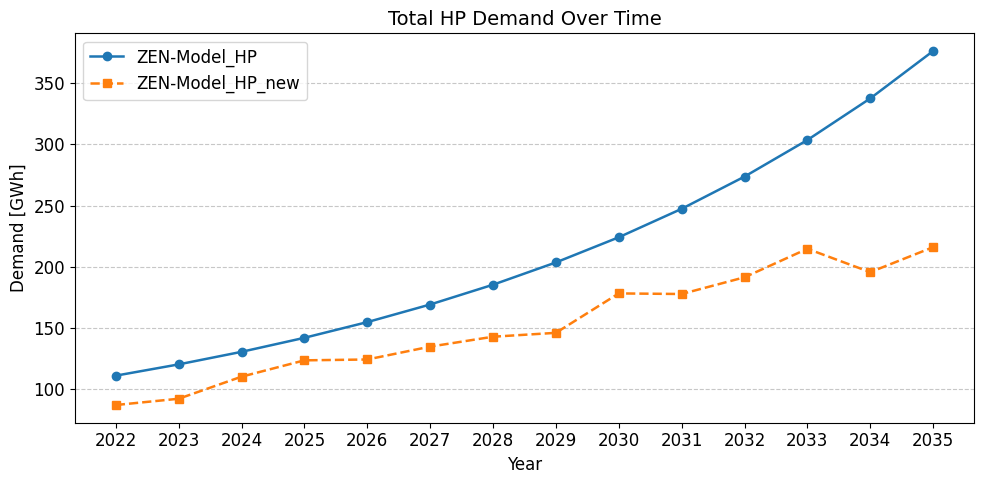

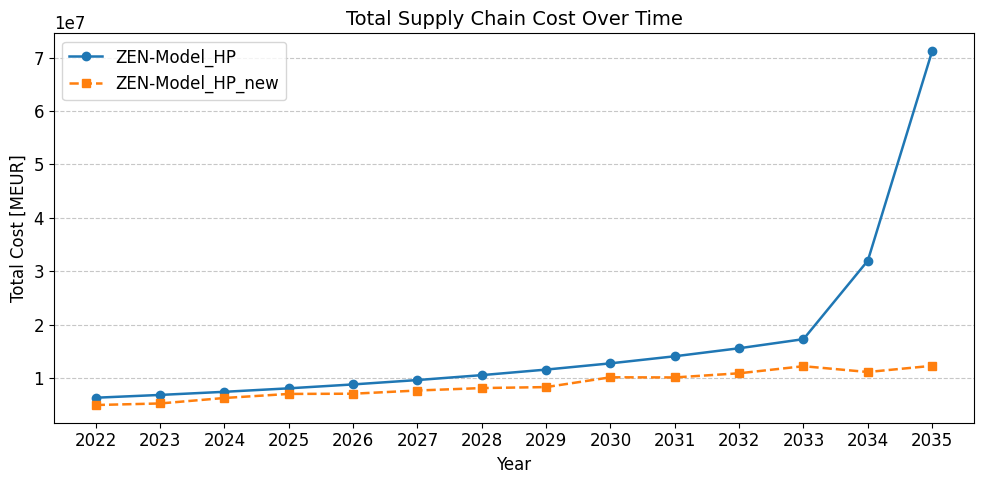


=== Heat Pump Demand by Node and Year ===

Node: DEU
  2022: WT = 1.89 GWh, WT_new = 0.00 GWh
  2023: WT = 2.21 GWh, WT_new = 0.00 GWh
  2024: WT = 2.58 GWh, WT_new = 0.00 GWh
  2025: WT = 3.02 GWh, WT_new = 0.00 GWh
  2026: WT = 3.54 GWh, WT_new = 0.00 GWh
  2027: WT = 4.14 GWh, WT_new = 0.00 GWh
  2028: WT = 4.84 GWh, WT_new = 0.00 GWh
  2029: WT = 5.67 GWh, WT_new = 0.00 GWh
  2030: WT = 6.63 GWh, WT_new = 9.98 GWh
  2031: WT = 7.76 GWh, WT_new = 3.11 GWh
  2032: WT = 9.08 GWh, WT_new = 5.64 GWh
  2033: WT = 10.62 GWh, WT_new = 12.09 GWh
  2034: WT = 12.42 GWh, WT_new = 7.06 GWh
  2035: WT = 14.54 GWh, WT_new = 5.71 GWh

Node: AUT
  2022: WT = 0.39 GWh, WT_new = 0.00 GWh
  2023: WT = 0.46 GWh, WT_new = 0.00 GWh
  2024: WT = 0.54 GWh, WT_new = 0.00 GWh
  2025: WT = 0.63 GWh, WT_new = 0.00 GWh
  2026: WT = 0.74 GWh, WT_new = 0.00 GWh
  2027: WT = 0.86 GWh, WT_new = 0.00 GWh
  2028: WT = 1.01 GWh, WT_new = 0.00 GWh
  2029: WT = 1.18 GWh, WT_new = 0.11 GWh
  2030: WT = 1.38 GWh, WT_new

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from zen_garden.postprocess.results import Results

# === Config ===
dataset_name_1 = 'ZEN-Model_HP'
dataset_name_2 = 'ZEN-Model_HP_new'
base_scenario = 'scenario_'
target_name = 'HP'
start_year = 2022
save_plots = True

# === Paths ===
output_path_1 = os.path.join("outputs", dataset_name_1)
output_path_2 = os.path.join("outputs", dataset_name_2)
r1 = Results(output_path_1)
r2 = Results(output_path_2)

save_path = Path(r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\SCM_plots\hp_comparison")
if save_plots:
    os.makedirs(save_path, exist_ok=True)

# === Style ===
plt.rcParams.update({'font.size': 12})
colors = {dataset_name_1: 'tab:blue', dataset_name_2: 'tab:orange'}
linestyles = {dataset_name_1: '-', dataset_name_2: '--'}
marker_styles = {dataset_name_1: 'o', dataset_name_2: 's'}
line_widths = {dataset_name_1: 1.8, dataset_name_2: 1.8}


def plot_hp_demand(var="demand", ylabel="Demand [GWh]", file_prefix="hp_demand"):
    try:
        df1 = r1.get_full_ts(var).reset_index().rename(columns={"level_0": "scenario"})
        df2 = r2.get_full_ts(var).reset_index().rename(columns={"level_0": "scenario"})

        df1 = df1[df1["scenario"] == base_scenario]
        df2 = df2[df2["scenario"] == base_scenario]

        time_cols = [col for col in df1.columns if isinstance(col, (int, float))]

        # Find grouping key
        group_key = next((k for k in ['carrier', 'technology', 'node'] if k in df1.columns and k in df2.columns), None)
        if not group_key:
            print(f"⚠️ No valid group key found in '{var}' — skipping.")
            return

        df1 = df1[df1[group_key] == target_name]
        df2 = df2[df2[group_key] == target_name]

        total1 = df1[time_cols].sum()
        total2 = df2[time_cols].sum()

        # Plot
        plt.figure(figsize=(10, 5))
        plt.plot(time_cols, total1, label=dataset_name_1, color=colors[dataset_name_1],
                 linestyle=linestyles[dataset_name_1], marker=marker_styles[dataset_name_1],
                 linewidth=line_widths[dataset_name_1])
        plt.plot(time_cols, total2, label=dataset_name_2, color=colors[dataset_name_2],
                 linestyle=linestyles[dataset_name_2], marker=marker_styles[dataset_name_2],
                 linewidth=line_widths[dataset_name_2])

        plt.title(f"Total HP Demand Over Time", fontsize=14)
        plt.xlabel("Year")
        plt.ylabel(ylabel)
        plt.grid(axis='y', linestyle="--", alpha=0.7)
        plt.legend(loc='upper left')
        plt.tight_layout()

        xtick_labels = [str(start_year + i) for i in range(len(time_cols))]
        plt.xticks(ticks=time_cols, labels=xtick_labels)

        if save_plots:
            filename = f"{file_prefix}.pdf"
            plt.savefig(save_path / filename, format='pdf', bbox_inches='tight')

        plt.show()

    except Exception as e:
        print(f"⚠️ Error plotting {var}: {e}")


def plot_total_cost(var="cost_total", ylabel="Total Cost [MEUR]", file_prefix="hp_total_cost"):
    try:
        df1 = r1.get_full_ts(var).reset_index()
        df2 = r2.get_full_ts(var).reset_index()

        time_cols = [col for col in df1.columns if isinstance(col, (int, float))]
        total1 = df1[time_cols].sum()
        total2 = df2[time_cols].sum()

        # Plotting
        plt.figure(figsize=(10, 5))
        plt.plot(
            time_cols, total1,
            label=dataset_name_1,
            color=colors[dataset_name_1],
            linestyle=linestyles[dataset_name_1],
            marker=marker_styles[dataset_name_1],
            linewidth=line_widths[dataset_name_1]
        )
        plt.plot(
            time_cols, total2,
            label=dataset_name_2,
            color=colors[dataset_name_2],
            linestyle=linestyles[dataset_name_2],
            marker=marker_styles[dataset_name_2],
            linewidth=line_widths[dataset_name_2]
        )

        plt.title("Total Supply Chain Cost Over Time", fontsize=14)
        plt.xlabel("Year")
        plt.ylabel(ylabel)
        plt.grid(axis='y', linestyle="--", alpha=0.7)
        plt.legend(loc='upper left')
        plt.tight_layout()

        xtick_labels = [str(start_year + i) for i in range(len(time_cols))]
        plt.xticks(ticks=time_cols, labels=xtick_labels)

        if save_plots:
            filename = f"{file_prefix}.pdf"
            plt.savefig(save_path / filename, format='pdf', bbox_inches='tight')

        plt.show()

    except Exception as e:
        print(f"⚠️ Error plotting {var}: {e}")


# === Plot Calls ===
plot_hp_demand()
plot_total_cost()

# === Export HP Demand Per Node and Year ===
try:
    nodes_of_interest = ["DEU", "AUT", "ITA", "CZE", "ROE"]
    export_folder = Path(r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\device_demand_data")
    os.makedirs(export_folder, exist_ok=True)

    df1 = r1.get_full_ts("demand").reset_index().rename(columns={"level_0": "scenario"})
    df2 = r2.get_full_ts("demand").reset_index().rename(columns={"level_0": "scenario"})

    df1 = df1[(df1["scenario"] == base_scenario) & (df1["carrier"] == target_name)]
    df2 = df2[(df2["scenario"] == base_scenario) & (df2["carrier"] == target_name)]

    time_cols = [col for col in df1.columns if isinstance(col, (int, float))]

    # Group and filter by node
    demand_by_node_1 = (
        df1[df1["node"].isin(nodes_of_interest)]
        .groupby("node")[time_cols]
        .sum()
        .reindex(nodes_of_interest)
    )
    demand_by_node_2 = (
        df2[df2["node"].isin(nodes_of_interest)]
        .groupby("node")[time_cols]
        .sum()
        .reindex(nodes_of_interest)
    )

    # Compute totals
    total1 = demand_by_node_1.sum()
    total2 = demand_by_node_2.sum()

    # Combine into one table
    combined = pd.concat([
        demand_by_node_1.add_suffix(" (WT)"),
        demand_by_node_2.add_suffix(" (WT_new)")
    ], axis=1)
    combined.loc["TOTAL"] = list(total1) + list(total2)

    # Save CSV
    combined.to_csv(export_folder / "hp_demand_by_node_and_total.csv")

    # Print Text Output
    print("\n=== Heat Pump Demand by Node and Year ===")
    for node in nodes_of_interest + ["TOTAL"]:
        print(f"\nNode: {node}")
        for i, year in enumerate(time_cols):
            val1 = demand_by_node_1.loc[node, year] if node in demand_by_node_1.index else total1[year]
            val2 = demand_by_node_2.loc[node, year] if node in demand_by_node_2.index else total2[year]
            print(f"  {start_year + i}: WT = {val1:.2f} GWh, WT_new = {val2:.2f} GWh")

except Exception as e:
    print(f"⚠️ Error exporting HP demand: {e}")
